In [9]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier


# Voting Classifier Recap
- Voting Classifier is an ensemble models that are fit to the same training set using different algorithms . You also saw that the final predictions were obtained by majority voting 
    - same training set 
    - various models 
- Begging the ensemble is formed by models that use the same training algorithm . However these models are not trained on the entire training set . Instead each model is trained on a different subset of the data 
    - one model
    - subset of training data


# Bagging
- Bagging : Bootstrap Aggregation 
- Uses a technique called bootstrap 
- Reduces Variance of individual models in ensemble 

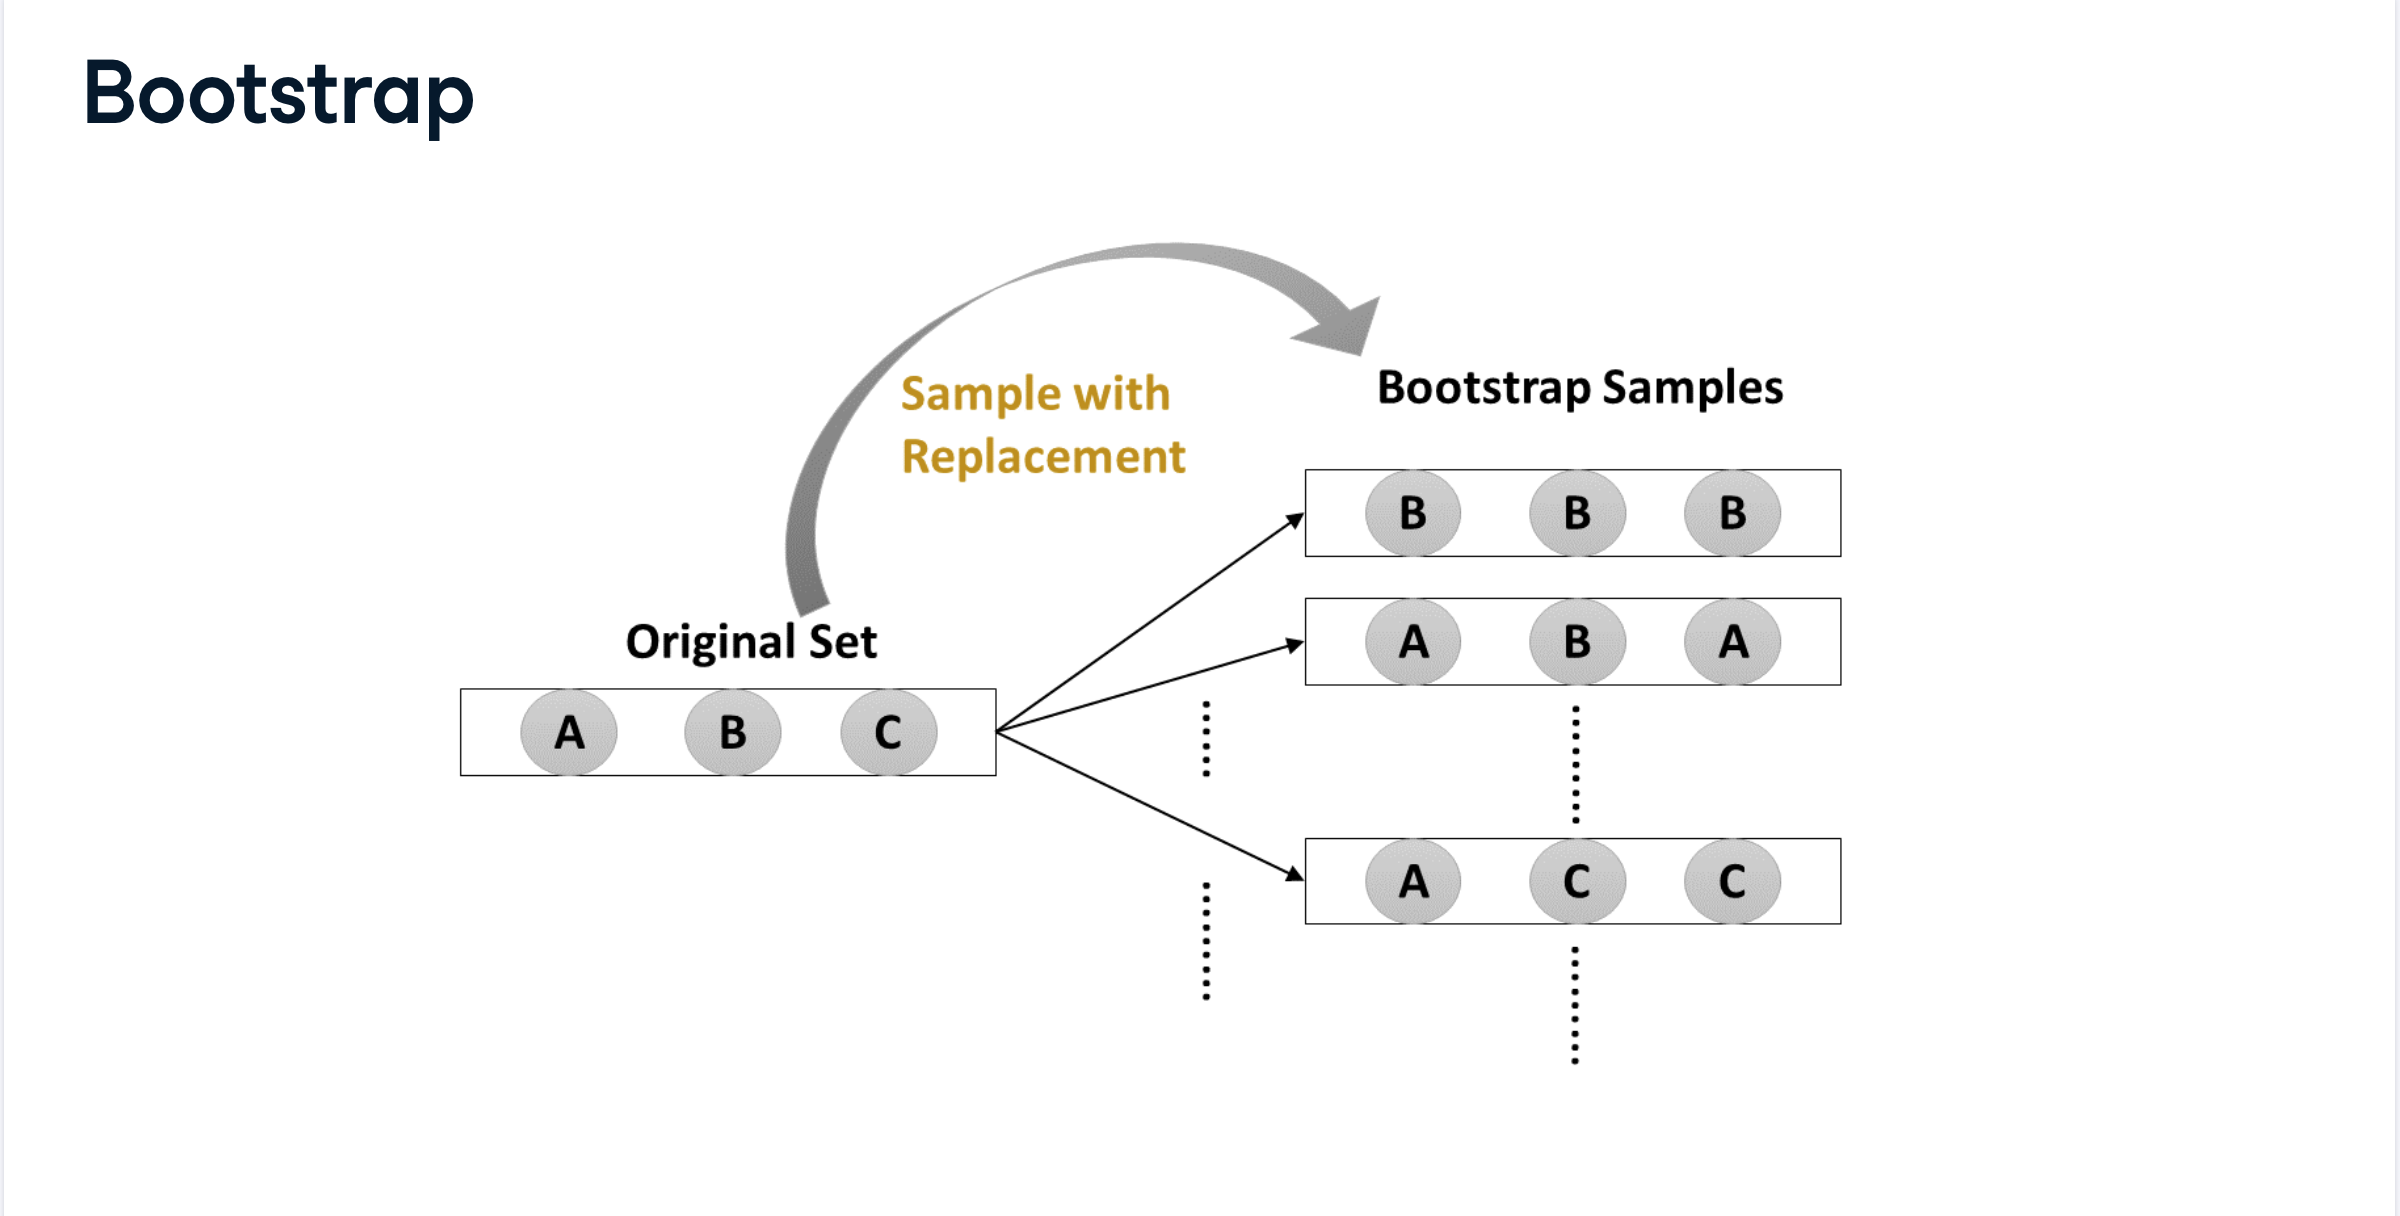

### How Bagging Works
- Consider the case you have 3 balls labeled A B C . A bootstrap sample is a sample drawn from this with replacement . By replacement we mean any ball can be drawn many times . For example in the first sample shown in the diagram here B was drawn 3 times in a row . In the second sample A was drawn two times while B was drawn once and so on 

### Bagging in training data 
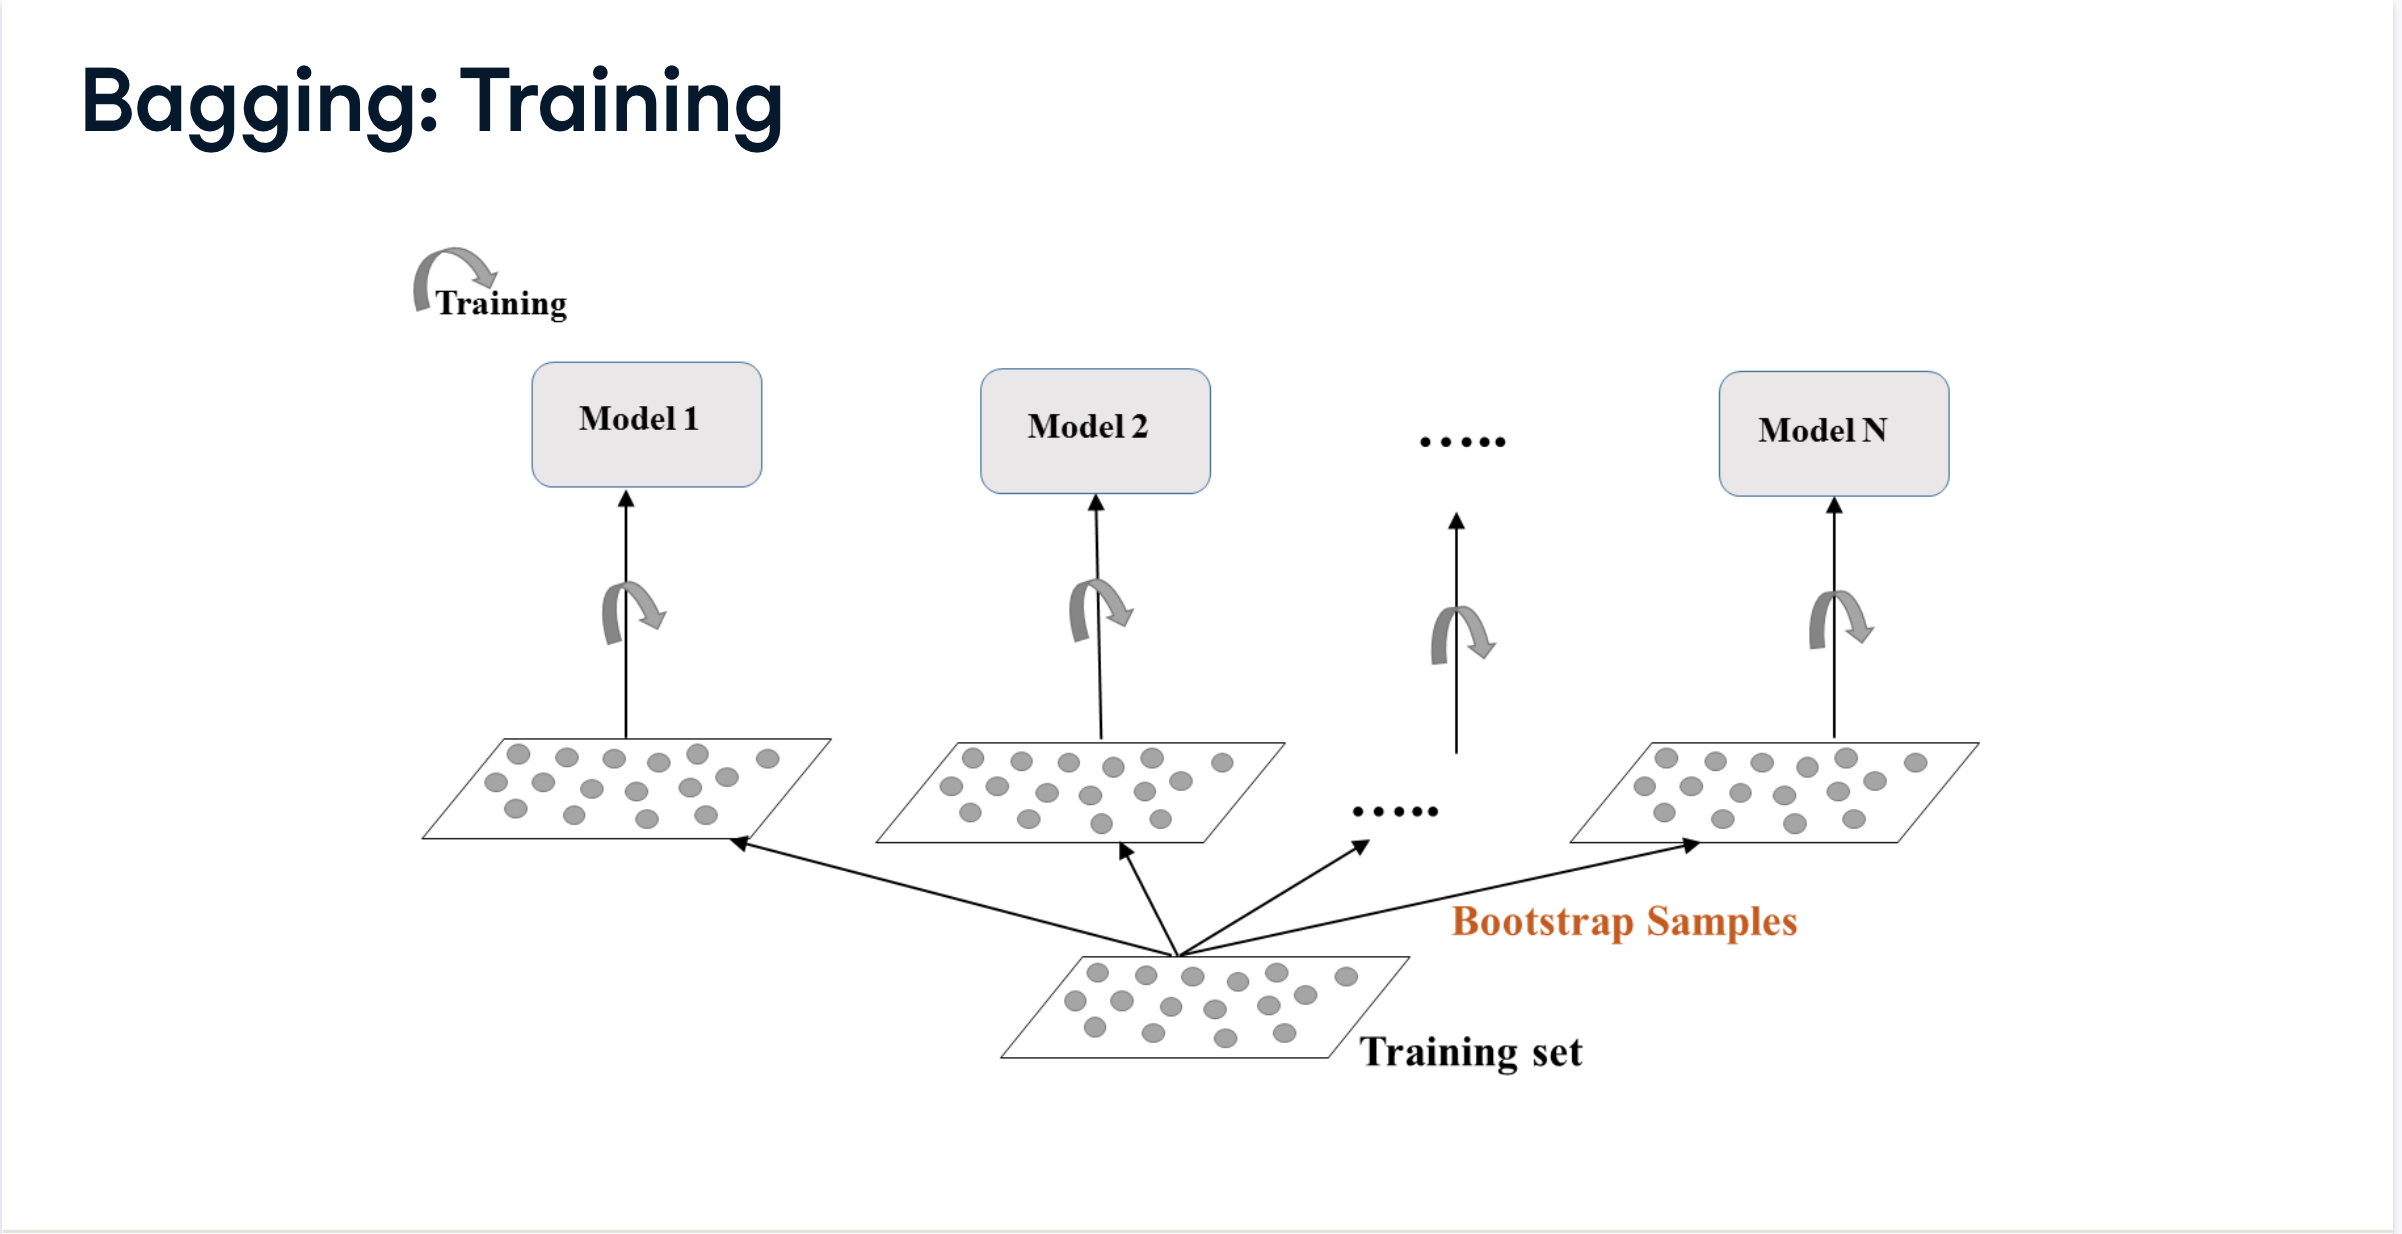

- Bagging consist of drawing N different bootstrap samples from the training set . As shown in the diagram below each of these bootstrap samples are used to train N models that use the same algorithm

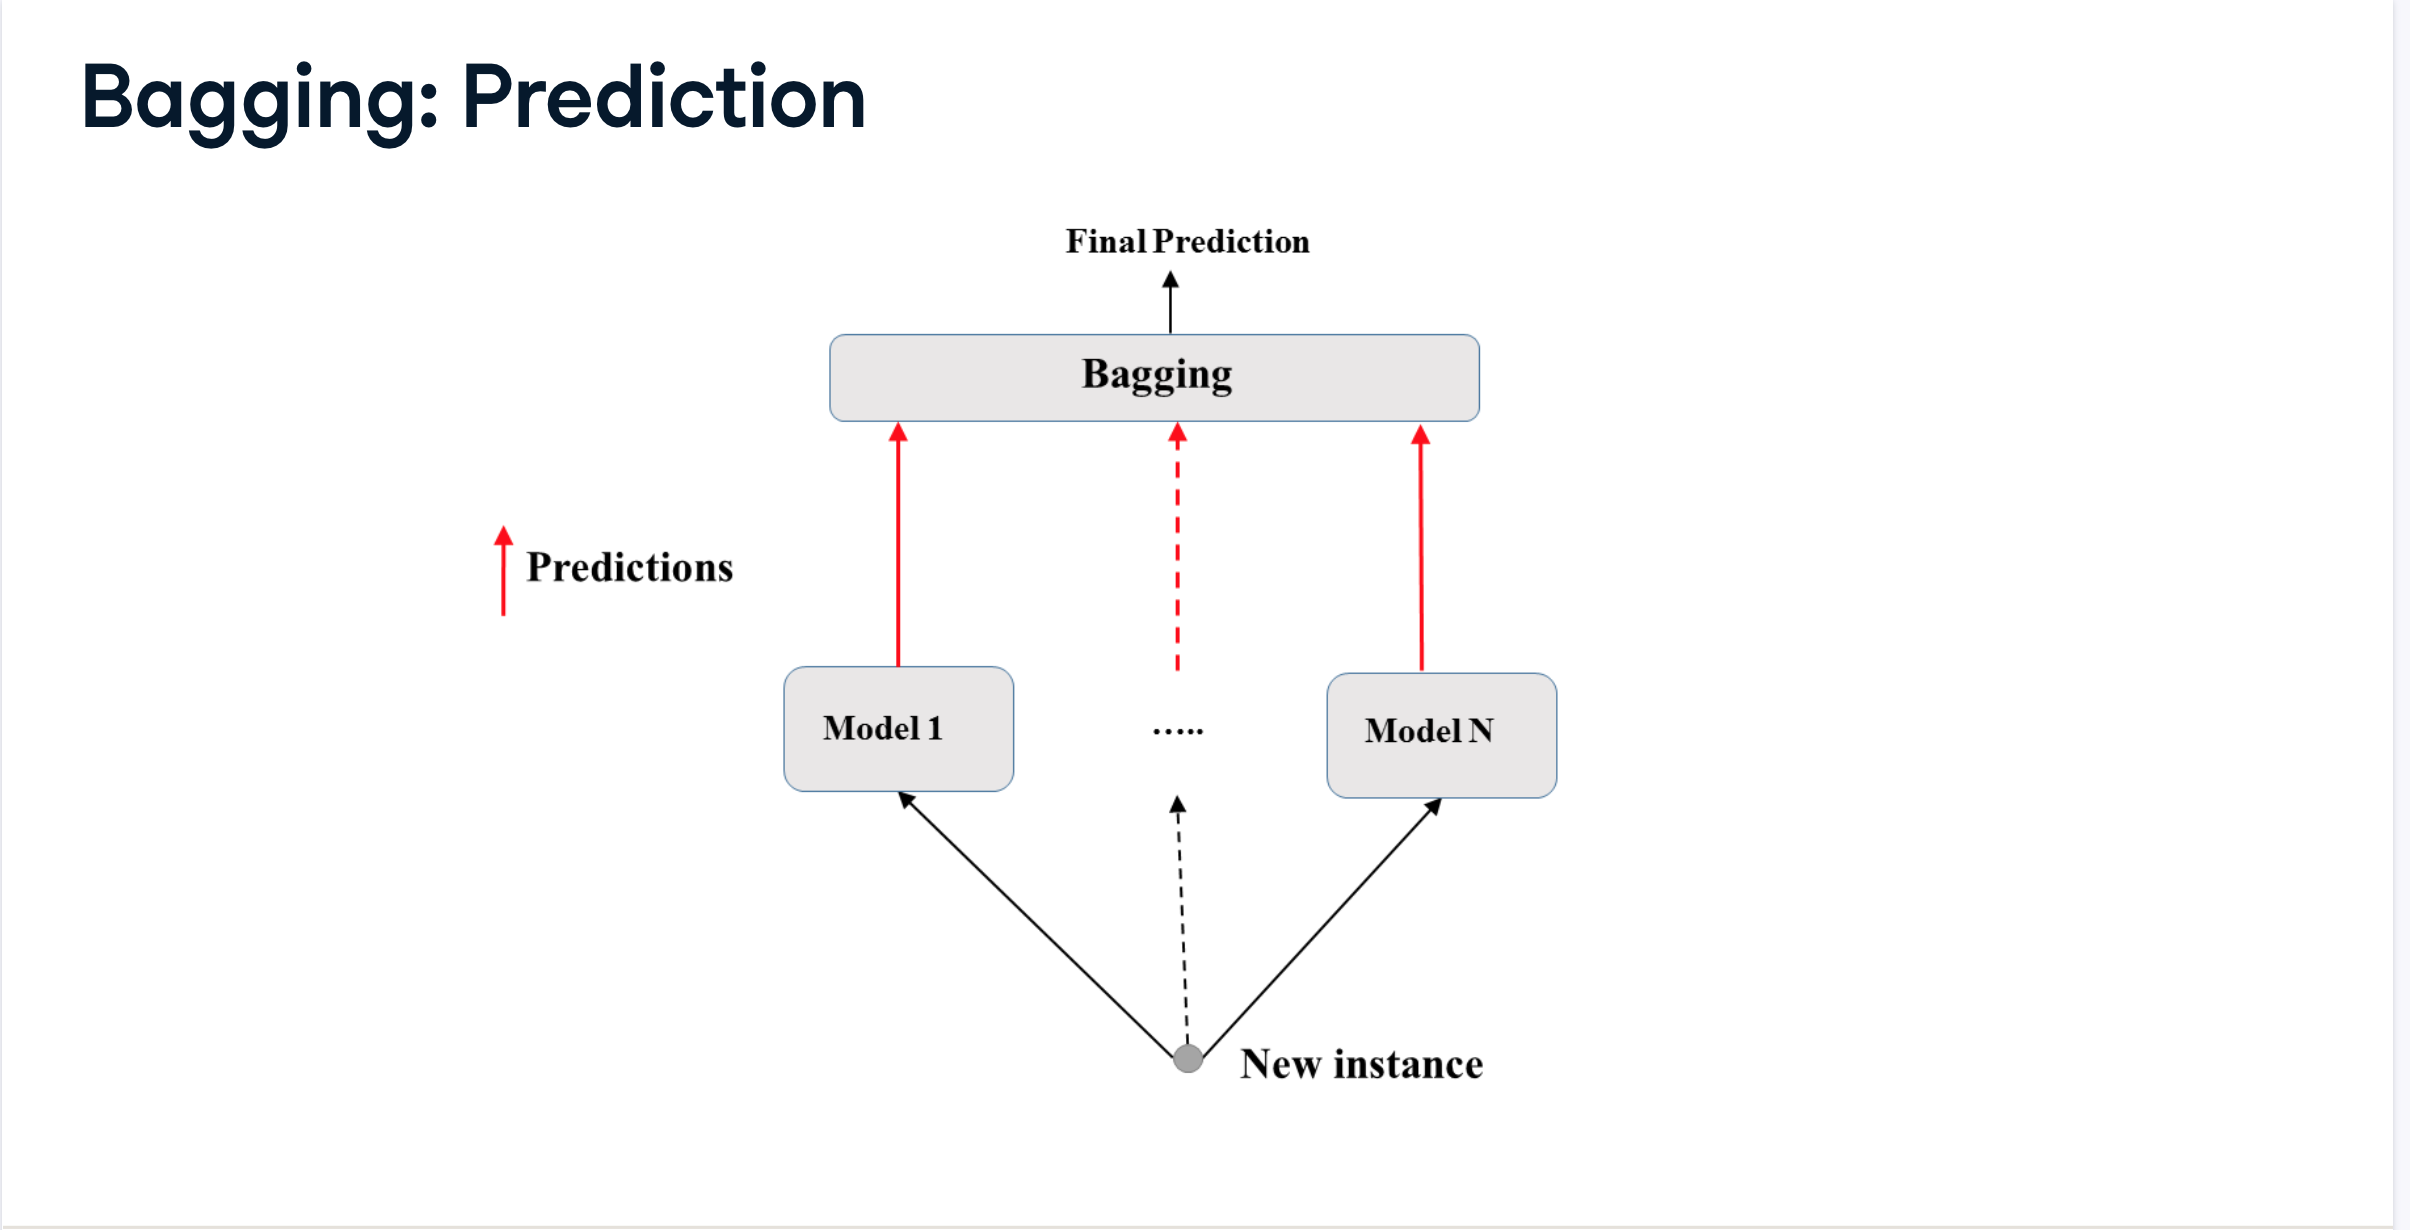

- When a new instance is fed to the different models forming the bagging ensemble , each model outputs its predictions . The meta model collects these predictions and outputs a final prediction depending on the nature of the problem


## Bagging Classifier and Regression
### Classification 
- Aggregates predictions by majority voting 
- **Bagging Classifier** in sickit learn

### Regression
- Aggregates predictions through averaging 
- **Bagging Regression** in sickit learn

In [8]:
df = pd.read_csv("breast-cancer.csv")

In [11]:
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()

SEED=1 

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.3, stratify=y_labels, random_state=SEED)

dt = DecisionTreeClassifier(max_depth=4,min_samples_leaf=0.16,random_state=SEED)
bc = BaggingClassifier(n_estimators=300,n_jobs=-1)

bc.fit(X_train,y_train)

y_pred = bc.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy of banging classifier: {:.3f}".format(accuracy))


Accuracy of banging classifier: 0.942


### Bagging Recall
- In bagging some instances may be sampled several times for one model . On the other hand other instances may not be sampled at all

# Out of Bag Evaluation
### OOB instances 
-  On average for each model 63% of the training instances are sampled 
- The remaning 37% constitutes OOB instances
- Since OOB instances are not seen by the a model during training , these can be used to estimate the performance of the ensemble the performace of the ensemble wihtout the need of cross-validation . This technique is known as OOB evaluation

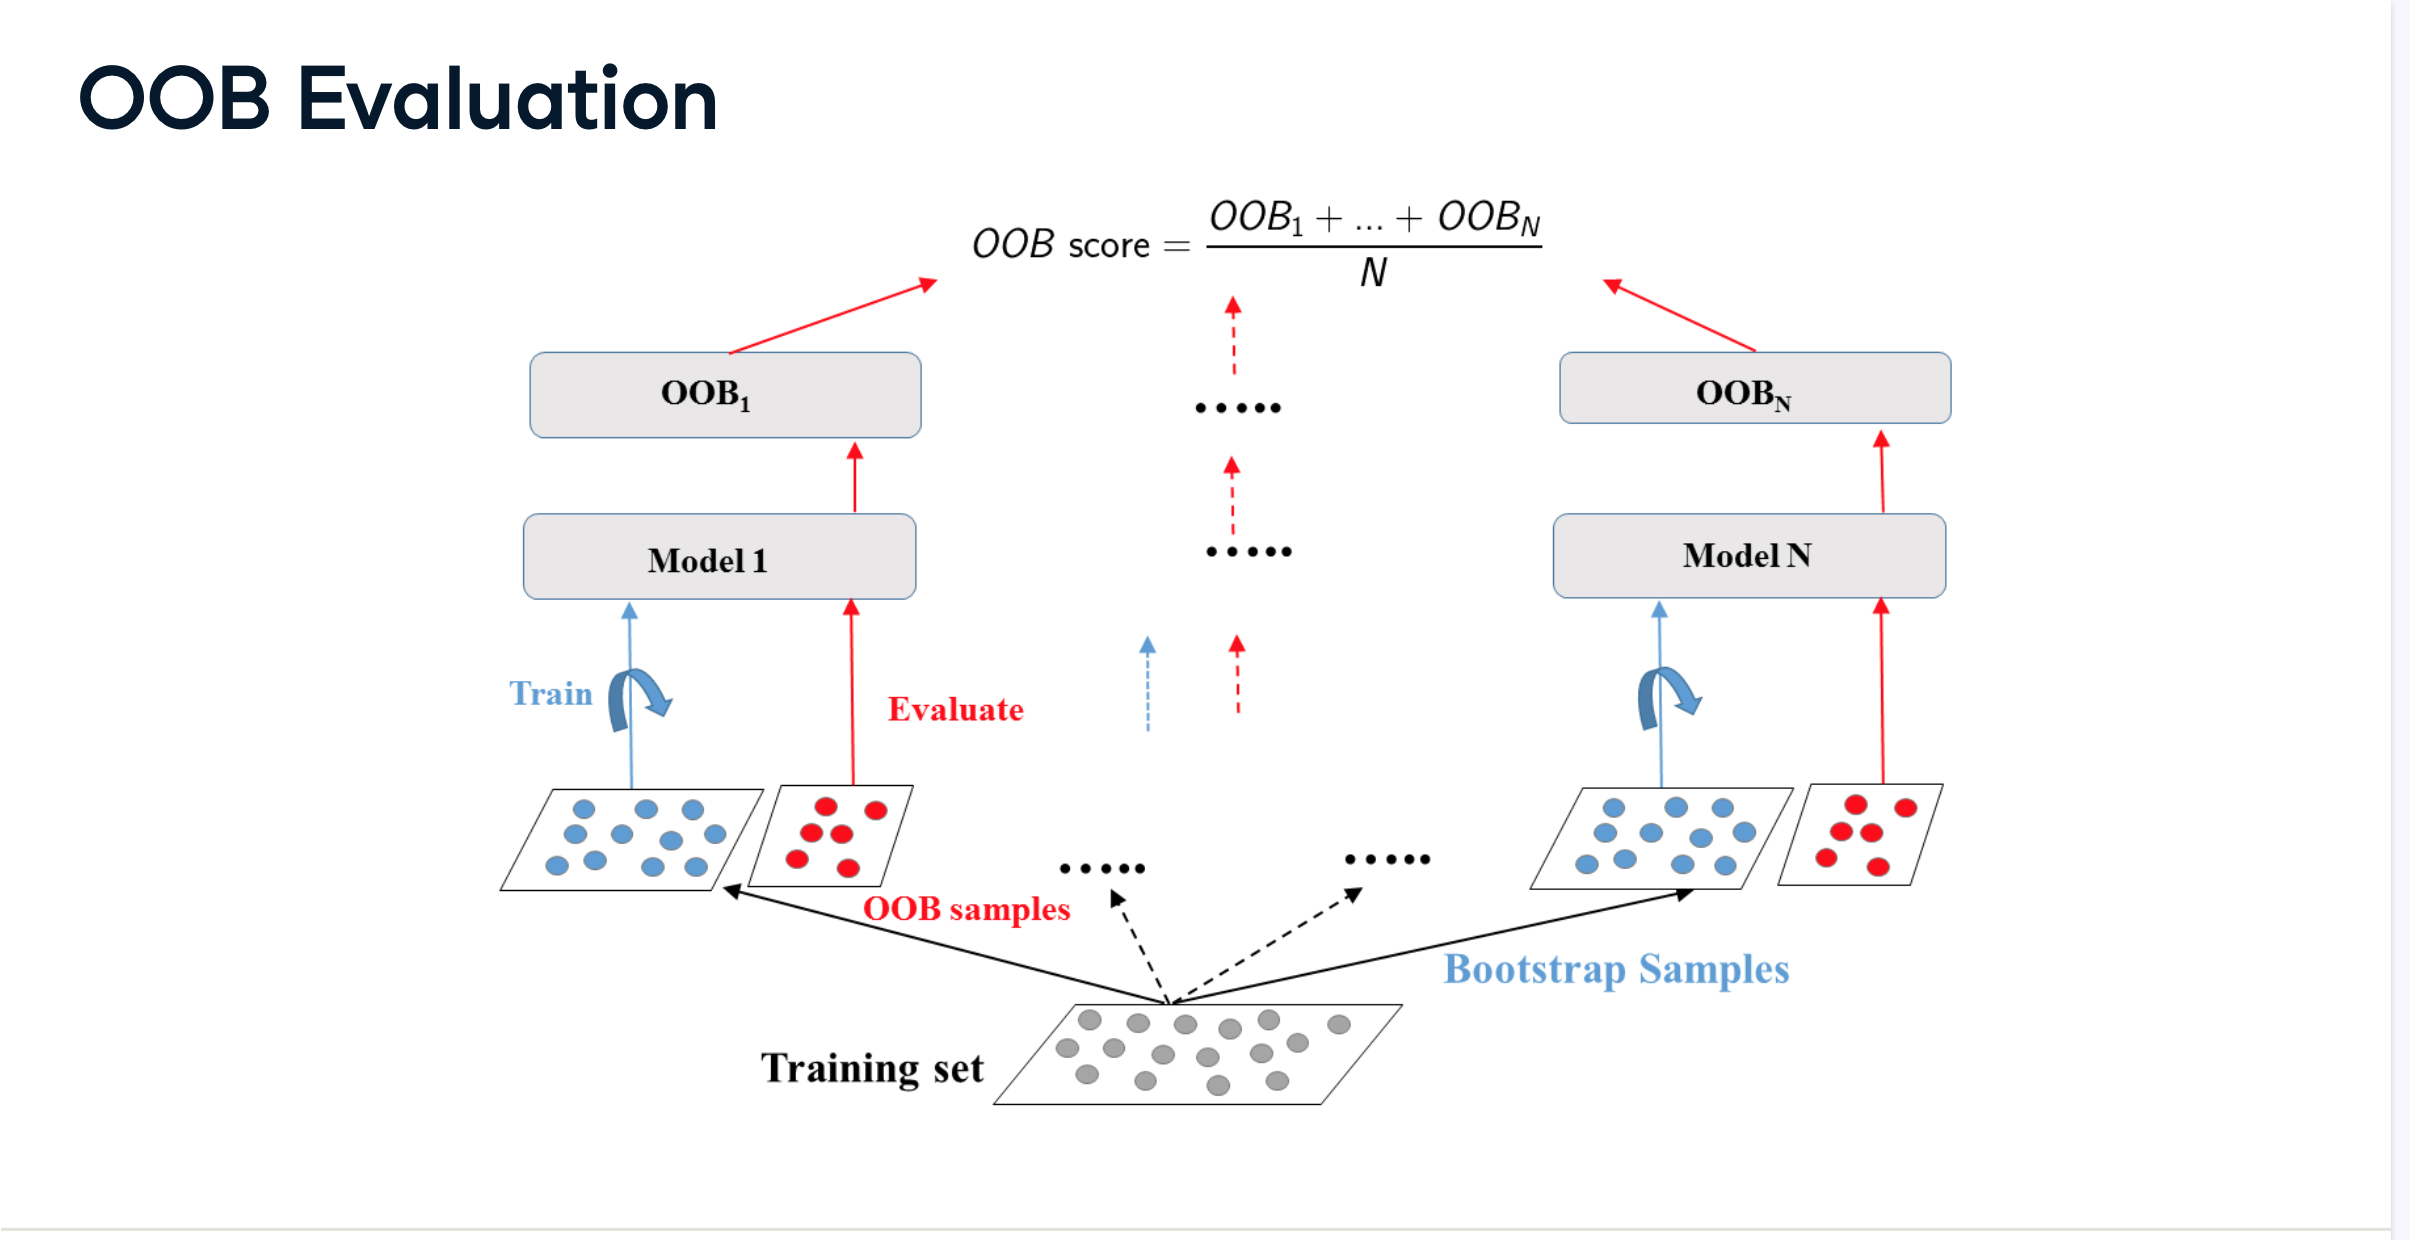

- To understand OOB-evaluation more concretely, take a look at this diagram. Here, for each model, the bootstrap instances are shown in blue while the OOB-instances are shown in red. Each of the N models constituting the ensemble is then trained on its corresponding bootstrap samples and evaluated on the OOB instances. This leads to the obtainment of N OOB scores labeled OOB1 to OOBN. The OOB-score of the bagging ensemble is evaluated as the average of these N OOB scores as shown by the formula on top.

In [13]:
X = df.drop('diagnosis', axis=1).to_numpy()
y_labels = df['diagnosis'].to_numpy()

SEED=1 

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.3, stratify=y_labels, random_state=SEED)

dt = DecisionTreeClassifier(max_depth=4,min_samples_leaf=0.16,random_state=SEED)
bc = BaggingClassifier(estimator=dt,oob_score=True,n_estimators=300,n_jobs=-1)


bc.fit(X_train,y_train)

y_pred = bc.predict(X_test)

test_accuracy = accuracy_score(y_test,y_pred)

oob_accuracy = bc.oob_score_

print("Test set accuracy : {:.3f}".format(test_accuracy))

print("OOB accuracy : {:.3f}".format(oob_accuracy))

Test set accuracy : 0.924
OOB accuracy : 0.920
